In [94]:
import argparse
import json
import tensorboard
import tensorboardX
import os
import re
import argparse
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 
import nni
from nni.nas.nn.pytorch import ModelSpace, LayerChoice, MutableConv2d, MutableBatchNorm2d, MutableReLU, MutableLinear
from nni.nas.experiment.config import NasExperimentConfig
from pytorch_lightning import Trainer
from nni.nas.evaluator.pytorch import Lightning, ClassificationModule, Trainer
from nni.nas.experiment import NasExperiment
from nni.nas.space import model_context
from nni.nas.hub.pytorch import DARTS
from nni.nas.strategy import DARTS as DartsStrategy
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
from torchvision.datasets import CIFAR10
from nni.nas.experiment import NasExperiment
from nni.nas.evaluator import FunctionalEvaluator
import nni.nas.strategy as strategy
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, random_split
from nni.experiment.config import utils, ExperimentConfig
from pytorch_lightning.callbacks import ModelCheckpoint
torch.set_float32_matmul_precision('medium')
from tqdm import tqdm
from nni.nas.nn.pytorch import LayerChoice, ModelSpace, ValueChoice
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from pytorch_lightning import LightningModule, Trainer
from torchvision import datasets, transforms
from nni.nas.evaluator.pytorch import Classification

# Import the quantized CustomDARTSSpace
import sys
import importlib
import DoReFaLayers
importlib.reload(DoReFaLayers)
from DoReFaLayers import MutableDoReFaConv2d, MutableDoReFaLinear, dorefa_activation, LSQWeightQuantizer
from nni.nas.oneshot.pytorch.supermodule.operation import MixedConv2d, MixedLinear


class QuantMixedConv2d(MixedConv2d):
    def _get_lsq_quantizer(self, bits: int, per_channel: bool):
        if not hasattr(self, "_lsq_weight_quantizers"):
            self._lsq_weight_quantizers = nn.ModuleDict()
        key = f"{bits}_{'pc' if per_channel else 'pt'}"
        if key not in self._lsq_weight_quantizers:
            self._lsq_weight_quantizers[key] = LSQWeightQuantizer(k=bits, per_channel=per_channel)
        return self._lsq_weight_quantizers[key]

    def forward_with_args(self, in_channels, out_channels, kernel_size, stride, padding, dilation, groups, inputs):
        if isinstance(stride, dict) or isinstance(dilation, dict):
            raise ValueError('Mutable stride/dilation is not supported in differentiable mode.')
        params_mapping = self._freeze_weight_impl(in_channels, out_channels, kernel_size, groups)
        weight, bias, in_channels_per_group = [params_mapping.get(name) for name in ['weight', 'bias', 'in_channels_per_group']]
        num_bits = getattr(self, 'num_bits', None)
        w_quant_bits = num_bits
        if num_bits is not None:
            quantizer = self._get_lsq_quantizer(w_quant_bits, per_channel=True)
            weight = quantizer(weight)
        if isinstance(groups, dict):
            if not isinstance(in_channels_per_group, (int, float)):
                raise ValueError(f'Input channels per group is not numeric: {in_channels_per_group}')
            if inputs.size(1) % in_channels_per_group != 0:
                raise RuntimeError(
                f'Input channels must be divisible by in_channels_per_group, but got input shape {inputs.size()} and '
                f'in_channels_per_group={in_channels_per_group}'
            )
            groups = inputs.size(1) // int(in_channels_per_group)
        if isinstance(kernel_size, dict):
            if isinstance(self.padding, str):
                raise ValueError(f'Use "{self.padding}" in padding is not supported.')
            padding = self.padding
        stride_ = self._to_tuple(stride)
        dilation_ = self._to_tuple(dilation)
        if self.padding_mode != 'zeros':
            return F.conv2d(
                F.pad(inputs, self._reversed_padding_repeated_twice, mode=self.padding_mode),
                weight, bias, stride_, (0, 0), dilation_, groups
            )
        return F.conv2d(inputs, weight, bias, stride_, padding, dilation_, groups)

    @classmethod
    def mutate(cls, module, name, memo, kwargs):
        mixed_op = super().mutate(module, name, memo, kwargs)
        if mixed_op is not None:
            mixed_op.num_bits = getattr(module, 'num_bits', None)
            mixed_op.max_epochs = getattr(module, "max_epochs", None)
            mixed_op.epoch = getattr(module, "epoch", None)
            if mixed_op.num_bits is not None:
                if not hasattr(module, "_lsq_weight_quantizers"):
                    module._lsq_weight_quantizers = nn.ModuleDict()
                mixed_op._lsq_weight_quantizers = module._lsq_weight_quantizers
                for bits in {int(mixed_op.num_bits)}:
                    key = f"{bits}_pc"
                    if key not in module._lsq_weight_quantizers:
                        quantizer = LSQWeightQuantizer(k=bits, per_channel=True)
                        quantizer.init_step_size(module.weight)
                        module._lsq_weight_quantizers[key] = quantizer
        return mixed_op

    def freeze(self, sample):
        arguments = {**self.init_arguments}
        for name, mutable in self.mutable_arguments.items():
            arguments[name] = mutable.freeze(sample)
        operation = self.bound_type(**arguments)
        state_dict = self.freeze_weight(**arguments)
        operation.load_state_dict(state_dict, strict=False)
        return operation


class SafeMixedLinear(MixedLinear):
    def _get_lsq_quantizer(self, bits: int, per_channel: bool):
        if not hasattr(self, "_lsq_weight_quantizers"):
            self._lsq_weight_quantizers = nn.ModuleDict()
        key = f"{bits}_{'pc' if per_channel else 'pt'}"
        if key not in self._lsq_weight_quantizers:
            self._lsq_weight_quantizers[key] = LSQWeightQuantizer(k=bits, per_channel=per_channel)
        return self._lsq_weight_quantizers[key]

    def forward_with_args(self, in_features, out_features, inputs):
        params_mapping = self.freeze_weight(in_features, out_features)
        weight, bias = [params_mapping.get(name) for name in ['weight', 'bias']]
        num_bits = getattr(self, 'num_bits', None)
        w_quant_bits = num_bits
        if num_bits is not None:
            quantizer = self._get_lsq_quantizer(w_quant_bits, per_channel=False)
            weight = quantizer(weight)
        return F.linear(inputs, weight, bias)

    @classmethod
    def mutate(cls, module, name, memo, kwargs):
        mixed_op = super().mutate(module, name, memo, kwargs)
        if mixed_op is not None:
            mixed_op.num_bits = getattr(module, 'num_bits', None)
            mixed_op.max_epochs = getattr(module, "max_epochs", None)
            mixed_op.epoch = getattr(module, "epoch", None)
            if mixed_op.num_bits is not None:
                if not hasattr(module, "_lsq_weight_quantizers"):
                    module._lsq_weight_quantizers = nn.ModuleDict()
                mixed_op._lsq_weight_quantizers = module._lsq_weight_quantizers
                for bits in {int(mixed_op.num_bits)}:
                    key = f"{bits}_pt"
                    if key not in module._lsq_weight_quantizers:
                        print(f"Initializing LSQ quantizer for {bits}-bit weight quantization in SafeMixedLinear.")
                        quantizer = LSQWeightQuantizer(k=bits, per_channel=False)
                        quantizer.init_step_size(module.weight)
                        module._lsq_weight_quantizers[key] = quantizer
        return mixed_op

    def freeze(self, sample):
        arguments = {**self.init_arguments}
        for name, mutable in self.mutable_arguments.items():
            arguments[name] = mutable.freeze(sample)
        operation = self.bound_type(**arguments)
        state_dict = self.freeze_weight(**arguments)
        operation.load_state_dict(state_dict, strict=False)
        return operation


def safe_mutable_conv_hook(module, name, memo, kwargs):
    if isinstance(module, MutableDoReFaConv2d):
        return QuantMixedConv2d.mutate(module, name, memo, kwargs)
    return False


def safe_mutable_linear_hook(module, name, memo, kwargs):
    if isinstance(module, MutableDoReFaLinear):
        return SafeMixedLinear.mutate(module, name, memo, kwargs)
    return False

In [2]:
def attach_lsq_step_size_hooks(model, every: int = 1):
    resolved = getattr(model, "_model", getattr(model, "model", model))
    handles = []
    for name, module in resolved.named_modules():
        if isinstance(module, LSQWeightQuantizer):
            def make_hook(module_name, mod):
                def hook(grad):
                    mod._lsq_step_print_count = getattr(mod, "_lsq_step_print_count", 0) + 1
                    if mod._lsq_step_print_count % every == 0:
                        step_preview = mod.step_size.detach().flatten()[:3].tolist()
                        print(
                            f"{module_name}.step_size={step_preview} grad_mean={grad.mean().item():.3e}"
                        )
                return hook
            handles.append(module.step_size.register_hook(make_hook(name, module)))
    print(f"Attached {len(handles)} LSQ step_size hooks.")
    return handles

def remove_lsq_step_size_hooks(handles):
    for handle in handles:
        handle.remove()

# Example usage (run after model/module creation):
# lsq_hooks = attach_lsq_step_size_hooks(module, every=1)
# ... run training step(s) ...
# remove_lsq_step_size_hooks(lsq_hooks)

In [3]:
def lsq_quantizer_uniqueness_report(model):
    resolved = getattr(model, "_model", getattr(model, "model", model))
    quantizers = []
    for module in resolved.modules():
        if isinstance(module, LSQWeightQuantizer):
            quantizers.append(module)
    unique_ids = {id(q) for q in quantizers}
    print(f"LSQ quantizers: {len(quantizers)} total, {len(unique_ids)} unique instances")

    by_owner = {}
    for name, module in resolved.named_modules():
        if hasattr(module, "_lsq_weight_quantizers") and isinstance(module._lsq_weight_quantizers, nn.ModuleDict):
            by_owner[name] = list(module._lsq_weight_quantizers.keys())
    if not by_owner:
        print("No modules with _lsq_weight_quantizers found.")
        return
    print("\nModules that own LSQ quantizers:")
    for name, keys in sorted(by_owner.items()):
        print(f"- {name}: {keys}")

# Example usage (run after model/module creation):
# lsq_quantizer_uniqueness_report(module)

In [4]:
import psutil
import os

p = psutil.Process(os.getpid())

p.nice(19)

# Quantized DARTS Architecture Search

This notebook performs NAS using the quantized CustomDARTSSpace with DoReFa quantization-aware training.

# Data Loading and Augmentation

In [5]:
def cutout_transform(img, length: int = 16):
    h, w = img.size(1), img.size(2)
    mask = np.ones((h, w), np.float32)
    y = np.random.randint(h)
    x = np.random.randint(w)

    y1 = np.clip(y - length // 2, 0, h)
    y2 = np.clip(y + length // 2, 0, h)
    x1 = np.clip(x - length // 2, 0, w)
    x2 = np.clip(x + length // 2, 0, w)

    mask[y1: y2, x1: x2] = 0.
    mask = torch.from_numpy(mask)
    mask = mask.expand_as(img)
    img *= mask
    return img

In [96]:
normalize = transforms.Normalize(
                (0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)
            ) 

def get_cifar10_dataset(train: bool = True, cutout: bool = False):
    if train:
        transform_list = [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            
        ]
        if cutout:
            transform_list.append(cutout_transform)
        transform = transforms.Compose(transform_list)
    else:
        transform = transforms.Compose([
            transforms.ToTensor(), 
        ])

    dataset = nni.trace(CIFAR10)(root='./data', train=train, download=True, transform=transform)
    
    return dataset

batch_size = 128
train_data = get_cifar10_dataset(cutout = True)
test_data = get_cifar10_dataset(train=False)

batch_size = 128

full_train_dataset = get_cifar10_dataset(
    train=True,
    cutout=True
)

# Example: 40k train / 10k validation
train_size = 40000
val_size = len(full_train_dataset) - train_size

print(f"Full training dataset size: {len(full_train_dataset)}")

generator = torch.Generator().manual_seed(42)

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Training subset size: {len(train_subset)}")
print(f"Validation subset size: {len(val_subset)}")


train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    pin_memory=True,
    num_workers=6,
    persistent_workers=True,
    shuffle=True,
)

valid_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False,
)

Full training dataset size: 50000
Training subset size: 40000
Validation subset size: 10000


# Classification Module

In [7]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}

        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.clone()

    def update(self, model):
        for name, p in model.named_parameters():
            if name in self.shadow:
                new_avg = self.decay * self.shadow[name] + (1 - self.decay) * p.data
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self, model):
        for name, p in model.named_parameters():
            if name in self.shadow:
                p.data = self.shadow[name]

    def restore(self, model, backup):
        for name, p in model.named_parameters():
            if name in backup:
                p.data = backup[name]

In [74]:
from nni.nas.oneshot.pytorch.supermodule.operation import (
    MixedConv2d,
    MixedLinear,
 )


@nni.trace
class DartsClassificationModule(ClassificationModule):
    def __init__(self, learning_rate: float = 0.001, 
                 weight_decay: float = 0., 
                 auxiliary_loss_weight=None, 
                 max_epochs: int = 600,
                 alpha_tracker=None,
                 auxiliary_exit_weights=None):
        super().__init__(learning_rate=learning_rate, 
                        weight_decay=weight_decay, 
                        export_onnx=False, 
                        num_classes=10)
        self.auxiliary_loss_weight = auxiliary_loss_weight
        self.auxiliary_exit_weights = auxiliary_exit_weights
        self.max_epochs = max_epochs
        self.alpha_tracker = alpha_tracker
        self._last_alpha_capture_epoch = None
        self.alpha_grads = {}
        self.learning_rate = learning_rate
        self._use_aux_exits = (auxiliary_loss_weight is not None) or (auxiliary_exit_weights is not None)
        self._logged_aux_mode = False
    
    def configure_optimizers(self):
        weight_params = []
        arch_params = []

        for name, p in self.named_parameters():
            if not p.requires_grad:
                continue

            if 'alpha' in name.lower():
                arch_params.append(p)
            else:
                weight_params.append(p)

        print(f"Weight params: {len(weight_params)}")
        print(f"Arch params (excluded): {len(arch_params)}")

        optimizer = torch.optim.SGD(
            weight_params,  # ✅ ONLY weights
            lr=self.learning_rate,
            momentum=0.9,
            weight_decay=0.
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=self.max_epochs, eta_min=0.001
            )
        }   

    def _sync_epoch_to_quant_modules(self, epoch: int) -> None:
        model = getattr(self, '_model', getattr(self, 'model', None))
        if model is None:
            return
        for module in model.modules():
            if hasattr(module, 'num_bits'):
                module.epoch = epoch
                module.max_epochs = self.max_epochs

    def _resolve_outputs(self, outputs):
        if isinstance(outputs, tuple) and len(outputs) == 2:
            y_hat, aux = outputs
            if isinstance(aux, list):
                return y_hat, aux
            return y_hat, [(-1, aux)]
        return outputs, []

    def _compute_aux_exit_loss(self, exit_logits, y):
        if not exit_logits or not self.auxiliary_loss_weight:
            return None
        weights = self.auxiliary_exit_weights
        if weights is None:
            weights = [self.auxiliary_loss_weight] * len(exit_logits)
        total = 0.0
        used = 0
        final_layer_index = None
        model = getattr(self, '_model', getattr(self, 'model', None))
        if model is not None and hasattr(model, 'layers'):
            final_layer_index = len(model.layers)
        for (layer_idx, logits), weight in zip(exit_logits, weights):
            if final_layer_index is not None and layer_idx == final_layer_index:
                continue
            total = total + float(weight) * self.criterion(logits, y)
            used += 1
        if used == 0:
            return None
        return total

    def training_step(self, batch, batch_idx):
        """Training step, customized with auxiliary loss."""
        x, y = batch
        epoch = self.trainer.current_epoch if self.trainer else 0
        self._sync_epoch_to_quant_modules(epoch)
        model = getattr(self, '_model', getattr(self, 'model', None))
        if model is None:
            raise RuntimeError('DartsClassificationModule has no attached model.')
        if self._use_aux_exits:
            #print("aux_exits:"+str(self._use_aux_exits)+"auxiliary_exit_weights:"+str(self.auxiliary_exit_weights)+"auxiliary_loss_weight:"+str(self.auxiliary_loss_weight))
            outputs = model(x, epoch=epoch, return_all_exits=True)
            y_hat, exit_logits = self._resolve_outputs(outputs)
        else:
            if not self._logged_aux_mode:
                print("Aux exits disabled: running standard forward without exit logits.")
                self._logged_aux_mode = True
            y_hat = model(x, epoch=epoch)
            exit_logits = []
        loss_main = self.criterion(y_hat, y)
        loss = loss_main
        aux_loss = self._compute_aux_exit_loss(exit_logits, y)
        if aux_loss is not None:
            loss = loss + aux_loss
            self.log('train_loss_aux', aux_loss)
        self.log('train_loss_main', loss_main)
        self.log('train_loss', loss, prog_bar=True)
        for name, metric in self.metrics.items():
            self.log('train_' + name, metric(y_hat, y), prog_bar=True)
        #if batch_idx % 100 == 0:  # Log alpha stats every 5 epochs to reduce overhead
            #self.log_alpha_grads()
            #self.log_alphas()
        return loss
    
    def log_alpha_grads(self):
        if not self.alpha_grads:
            print("No alpha gradients recorded yet.")
            return

        print("\n=== Alpha Gradient Stats ===")
        for name, g in self.alpha_grads.items():
            mean = g.mean().item()
            std = g.std().item()
            print(f"{name}: mean={mean:.6e}, std={std:.6e}")
    
    def log_alphas(self):
        print("\n=== Alpha Values ===")
        for name, p in self.named_parameters():
            if 'alpha' in name.lower():
                probs = torch.softmax(p, dim=-1)
                print(f"{name}: {probs.detach().cpu().numpy()}")

    def get_temperature(self, epoch, max_epochs):
        # cosine decay from 5 → 0.1
        import math
        T_max = 5.0
        T_min = 0.1
        return T_min + 0.5 * (T_max - T_min) * (1 + math.cos(math.pi * epoch / max_epochs))

    def apply_alpha_temperature(self, T):
        for name, p in self.named_parameters():
            if 'alpha' in name.lower():
                p.data = p.data / T

    def on_train_epoch_start(self):
        # Logging learning rate at the beginning of every epoch
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])
        #self.ema = EMA(self.model, decay=0.999)
        #epoch = self.trainer.current_epoch
        #T = self.get_temperature(epoch, self.max_epochs)

        #self.apply_alpha_temperature(T)

        #self.log('temperature', T)
    
    def on_after_backward(self):
        # print("\n===== GRAD DEBUG =====")

        # for name, p in self.named_parameters():

        #     if not p.requires_grad:
        #         continue

        #     if p.grad is None:
        #         print(f"{name:60s} NO_GRAD")
        #     else:
        #         print(
        #             f"{name:60s} "
        #             f"grad_mean={p.grad.abs().mean().item():.3e} "
        #             f"param_mean={p.data.abs().mean().item():.3e}"
        #         )
        return
    def attach_alpha_hooks(self):
        """Register backward hooks to capture gradients of architecture parameters."""
        for name, p in self.named_parameters():
            if p.requires_grad and 'alpha' in name.lower():

                def make_hook(name):
                    def hook(grad):
                        self.alpha_grads[name] = grad.detach().clone()
                    return hook

                p.register_hook(make_hook(name))
                
    def on_train_start(self):
        self.attach_alpha_hooks()
        print("\n=== Attached alpha gradient hooks ===\n")

    def _capture_alphas_once_per_epoch(self, hook_name: str):
        if self.alpha_tracker is None:
            return

        epoch = int(self.trainer.current_epoch)
        if self._last_alpha_capture_epoch == epoch:
            return

        try:
            self.alpha_tracker.capture_alphas(self, epoch)
            self._last_alpha_capture_epoch = epoch
            # print(f"AlphaTracker: captured at epoch {epoch} from {hook_name}")
        except Exception as e:
            print(f"Alpha capture failed at epoch {epoch} during {hook_name}: {e}")

    def on_train_epoch_end(self):
        self._capture_alphas_once_per_epoch("epoch_end")

    def on_validation_epoch_end(self):
        self._capture_alphas_once_per_epoch("on_validation_epoch_end")



    

In [ ]:
# Patch DartsClassificationModule to explicitly log validation metrics on the progress bar
def _patched_validation_step(self, batch, batch_idx):
    x, y = batch
    epoch = self.trainer.current_epoch if self.trainer else 0
    self._sync_epoch_to_quant_modules(epoch)
    model = getattr(self, '_model', getattr(self, 'model', None))
    if model is None:
        raise RuntimeError('DartsClassificationModule has no attached model.')
    y_hat = model(x, epoch=epoch)
    loss = self.criterion(y_hat, y)
    self.log('val_loss', loss, prog_bar=True, on_step=False, on_epoch=True)
    for name, metric in self.metrics.items():
        self.log('val_' + name, metric(y_hat, y), prog_bar=True, on_step=False, on_epoch=True)
    return loss

DartsClassificationModule.validation_step = _patched_validation_step
print('Patched DartsClassificationModule.validation_step to log val_loss and val_* metrics.')

In [9]:
class DepthwiseSeparableBlock(nn.Module):
    """
    MobileNet-style depthwise separable block.
    """

    def __init__(self, in_channels, out_channels, stride, num_bits):
        super().__init__()

        self.block = nn.Sequential(
            MutableDoReFaConv2d(
                in_channels,
                in_channels,
                kernel_size=3,
                padding=1,
                stride = stride,
                groups=in_channels,
                bias=False,
                num_bits=num_bits,
            ),

            MutableBatchNorm2d(in_channels),
            MutableReLU(),

            # pointwise
            MutableDoReFaConv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                bias=False,
                num_bits=num_bits,
            ),

            MutableBatchNorm2d(out_channels),
            MutableReLU(),
        )

    def forward(self, x):
        return self.block(x)

In [ ]:
class ActQuant(nn.Module):
    def __init__(self, k=6, init_step=0.5):
        super().__init__()

        self.k = k

        # learned quantization step size
        self.step_size = nn.Parameter(torch.tensor(init_step))

        self.alpha = nn.Parameter(torch.tensor(6.0))

    def forward(self, x):

        # positive step size
        s = torch.clamp(self.step_size, min=1e-8)

        Qn = 0 # -(2 ** (self.k - 1))
        Qp = (2 ** self.k) - 1

        # scale gradient like LSQ paper
        grad_scale = 1.0 / ((Qp * x.numel()) ** 0.5)

        s_scale = (s - s.detach()) * grad_scale + s.detach()

        alpha = torch.clamp(self.alpha, min=1e-8)


        x = torch.clamp(x, torch.zeros_like(x), alpha)
        # quantize
        x_div = x / s_scale
        x_clamped = torch.clamp(x_div, Qn, Qp)

        x_q = torch.round(x_clamped)

        # STE
        x_q = x_clamped + (x_q - x_clamped).detach()

        return x_q * s_scale

class ResidualBlock(nn.Module):
    def __init__(self, op: nn.Module, in_channels: int, out_channels: int, num_bits: int):
        super().__init__()
        self.op = op
        if in_channels != out_channels:
            self.proj = nn.Sequential(
                MutableDoReFaConv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=1,
                    bias=False,
                    num_bits=num_bits,
                ),
                MutableBatchNorm2d(out_channels),
            )
        else:
            self.proj = nn.Identity()
        self.post_relu = MutableReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.op(x)
        res = self.proj(x)
        #print(f"Residual block: op output shape {out.shape}, residual shape {res.shape}")
        return self.post_relu(out + res * 0.5)


class SkipConnect(nn.Module):
    def __init__(self, in_channels, out_channels, num_bits):
        super().__init__()
        if in_channels == out_channels:
            self.op = nn.Identity()
        else:
            # Cheap 1x1 projection to match channel dimensions
            self.op = nn.Sequential(
                MutableDoReFaConv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=False,
                    num_bits=num_bits,
                ),
                MutableBatchNorm2d(out_channels)
            )

    def forward(self, x):
        return self.op(x)

class CustomDARTSSpaceResidual(ModelSpace):
    """CustomDARTSSpace with always-on residuals inside each block."""

    def __init__(
        self,
        input_channels: int = 3,
        channels: int = 64,
        num_classes: int = 10,
        layers: int = 7,
        verbose: int = 0,
        drop_path_prob: float = 0.1,
        num_bits: int = 2,
        max_epochs: int = 200,
    ):
        super().__init__()
        self.layers = nn.ModuleList()
        self.downsamples = nn.ModuleList()
        self.drop_path_prob = drop_path_prob
        self.verbose = verbose
        self.max_epochs = max_epochs
        self.num_bits = num_bits
        self.downsample_indices = {1, 3, 6}

        layer0_out = 64
        layer1_out = 64
        layer2_out = 128
        layer3_out = 128
        layer4_out = 256
        layer5_out = 256
        layer6_out = 256
        layer7_out = 512

        self.preliminary_layer = MutableDoReFaConv2d(
            input_channels,
            layer0_out,
            kernel_size=3,
            padding=1,
            bias=False,
            num_bits=num_bits,
        )
        self.layer0_bn = MutableBatchNorm2d(layer0_out)
        self.layer0_relu = MutableReLU()

        def _downsample_choice(channels, label):
            return LayerChoice(
                [
                    nn.AvgPool2d(kernel_size=2, stride=2),
                    nn.Sequential(
                        MutableDoReFaConv2d(
                            channels,
                            channels,
                            kernel_size=1,
                            stride=2,
                            bias=False,
                            num_bits=num_bits,
                        ),
                        MutableBatchNorm2d(channels),
                    ),
                ],
                label=label,
            )

        def _residual_layer(op_choice: nn.Module, in_ch: int, out_ch: int):
            return ResidualBlock(op_choice, in_ch, out_ch, num_bits)

        layer1_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer0_out,
                        layer1_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer1_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer0_out,
                    layer1_out,
                    stride=1,
                    num_bits=num_bits,
                ),
                SkipConnect(layer0_out, layer1_out, num_bits),
            ],
            label="layer_1_op",
        )
        self.layers.append(_residual_layer(layer1_op, layer0_out, layer1_out))
        self.downsamples.append(nn.Identity())

        layer2_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer1_out,
                        layer2_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer2_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer1_out,
                    layer2_out,
                    stride=1,
                    num_bits=num_bits,
                ),
            ],
            label="layer_2_op",
        )
        self.layers.append(_residual_layer(layer2_op, layer1_out, layer2_out))
        self.downsamples.append(_downsample_choice(layer2_out, "layer_2_down"))

        layer3_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer2_out,
                        layer3_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer3_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer2_out,
                    layer3_out,
                    stride=1,
                    num_bits=num_bits,
                ),
                SkipConnect(layer2_out, layer3_out, num_bits),
            ],
            label="layer_3_op",
        )
        self.layers.append(_residual_layer(layer3_op, layer2_out, layer3_out))
        self.downsamples.append(nn.Identity())

        layer4_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer3_out,
                        layer4_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer4_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer3_out,
                    layer4_out,
                    stride=1,
                    num_bits=num_bits,
                ),
            ],
            label="layer_4_op",
        )
        self.layers.append(_residual_layer(layer4_op, layer3_out, layer4_out))
        self.downsamples.append(_downsample_choice(layer4_out, "layer_4_down"))

        layer5_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer4_out,
                        layer5_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer5_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer4_out,
                    layer5_out,
                    stride=1,
                    num_bits=num_bits,
                ),
                SkipConnect(layer4_out, layer5_out, num_bits),
            ],
            label="layer_5_op",
        )
        self.layers.append(_residual_layer(layer5_op, layer4_out, layer5_out))
        self.downsamples.append(nn.Identity())

        layer6_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer5_out,
                        layer6_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer6_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer5_out,
                    layer6_out,
                    stride=1,
                    num_bits=num_bits,
                ),
                SkipConnect(layer5_out, layer6_out, num_bits),
            ],
            label="layer_6_op",
        )
        self.layers.append(_residual_layer(layer6_op, layer5_out, layer6_out))
        self.downsamples.append(nn.Identity())

        layer7_op = LayerChoice(
            [
                nn.Sequential(
                    MutableDoReFaConv2d(
                        layer6_out,
                        layer7_out,
                        kernel_size=3,
                        stride=1,
                        padding=1,
                        bias=False,
                        num_bits=num_bits,
                    ),
                    MutableBatchNorm2d(layer7_out),
                    MutableReLU(),
                ),
                DepthwiseSeparableBlock(
                    layer6_out,
                    layer7_out,
                    stride=1,
                    num_bits=num_bits,
                ),
            ],
            label="layer_7_op",
        )
        self.layers.append(_residual_layer(layer7_op, layer6_out, layer7_out))
        self.downsamples.append(_downsample_choice(layer7_out, "layer_7_down"))

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = MutableDoReFaLinear(layer7_out, num_classes, num_bits=num_bits)
        self.epoch = 0

        self.actQuantPre = ActQuant(k=num_bits)
        self.actQuantPost = ActQuant(k=num_bits)
        self.actQuants = nn.ModuleList([
            ActQuant(k=num_bits) for _ in range(layers)
        ])

    def init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor, epoch: int = 0) -> torch.Tensor:
        self.epoch = epoch
        act_quant_bits = self.num_bits # if epoch < self.max_epochs // 3 else self.num_bits
        #if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
            #act_quant_bits2 = 8
            #x = dorefa_activation(x, act_quant_bits2)
        #elif epoch >= 2 * self.max_epochs // 3:
        act_quant_bits2 = self.num_bits # 6
        x = self.actQuantPre(x)
        x = self.preliminary_layer(x)
        x = self.layer0_bn(x)
        x = self.layer0_relu(x)
        if self.verbose == 1:
            print(f"After preliminary layer: {x.shape}")

        for i, layer in enumerate(self.layers):
            x = self.actQuants[i](x)
            x = layer(x)
            if self.verbose == 1:
                print(f"After layer {i + 1}: {x.shape}")
            if i in self.downsample_indices:
                downsample = self.downsamples[i]
                x = downsample(x)
                if self.verbose == 1:
                    print(f"After downsample choice {i + 1}: {x.shape}")

        x = self.pool(x)
        x = torch.flatten(x, 1)
        # if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
        #     act_quant_bits2 = 8
        #     x = dorefa_activation(x, act_quant_bits2)
        # elif epoch >= 2 * self.max_epochs // 3:
        act_quant_bits2 = self.num_bits # 6
        x = self.actQuantPost(x)
        x = self.classifier(x)
        if self.verbose == 1:
            print(f"After classifier: {x.shape}")

        return x

    def set_drop_path_prob(self, drop_path_prob: float):
        self.drop_path_prob = drop_path_prob
        for layer in self.layers:
            if hasattr(layer, "set_drop_path_prob"):
                layer.set_drop_path_prob(drop_path_prob)


# Optional: keep the original name for downstream cells without edits.
CustomDARTSSpace = CustomDARTSSpaceResidual

# Evaluator Setup

Checkpoint callback and Lightning Evaluator configuration

In [11]:
# Checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor='train_acc', 
    dirpath='./checkpoints',
    filename='best-checkpoint',
    save_top_k=1,
    mode='max'
)

In [12]:
# Alpha Evolution Tracking and Visualization
# This cell prepares infrastructure to track architecture parameter (alpha) evolution during training

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

class AlphaTracker:
    """Track architecture parameters (alphas) throughout training and persist them to disk."""
    
    def __init__(self, save_path: str | None = None):
        self.history = []
        self.choice_names = []
        self.num_choices_per_layer = {}
        self.save_path = save_path
    
    def _resolve_model(self, model):
        return getattr(model, '_model', getattr(model, 'model', model))

    def _save_history(self):
        if self.save_path:
            os.makedirs(os.path.dirname(self.save_path) or '.', exist_ok=True)
            torch.save(self.history, self.save_path)
    
    def capture_alphas(self, model, epoch):
        """Capture current alpha values from the model."""
        resolved_model = self._resolve_model(model)
        alphas_snapshot = {}
        
        # Extract all arch_alpha tensors from the model
        for name, param in resolved_model.named_parameters():
            if '_arch_alpha' in name:
                # name format: layers.0._arch_alpha or layers.0.1._arch_alpha.feature1
                alphas_snapshot[name] = param.detach().cpu().clone()
                
                # Extract the choice name if it exists
                if '._arch_alpha.' in name:
                    choice_name = name.split('._arch_alpha.')[1]
                else:
                    # Extract from module path
                    parts = name.split('.')
                    layer_idx = parts[1] if len(parts) > 1 else 'unknown'
                    choice_name = f'layer_{int(layer_idx)+1}'
                
                if choice_name not in self.choice_names:
                    self.choice_names.append(choice_name)
                    self.num_choices_per_layer[choice_name] = alphas_snapshot[name].shape[0]
        
        # Store epoch data only if we actually found alpha tensors
        if alphas_snapshot:
            self.history.append({
                'epoch': epoch,
                'alphas': alphas_snapshot
            })
            self._save_history()
        else:
            print(f"AlphaTracker: no _arch_alpha tensors found at epoch {epoch}; resolved model type = {type(resolved_model).__name__}")
    
    def get_alpha_statistics(self):
        """Compute statistics about alpha evolution."""
        if not self.history:
            return None
        
        stats = {}
        for choice_name in self.choice_names:
            stats[choice_name] = {
                'initial': [],
                'final': [],
                'entropy_evolution': [],
                'max_prob_evolution': [],
                'winning_choice_evolution': []
            }
        
        # Iterate through epochs
        for epoch_data in self.history:
            alphas = epoch_data['alphas']
            
            for name, alpha_tensor in alphas.items():
                if '._arch_alpha.' in name:
                    choice_name = name.split('._arch_alpha.')[1]
                else:
                    parts = name.split('.')
                    choice_name = f'layer_{int(parts[1])+1}' if len(parts) > 1 else 'unknown'
                
                if choice_name in stats:
                    # Compute softmax to get probabilities
                    probs = torch.softmax(alpha_tensor, dim=0).numpy()
                    
                    # Entropy
                    entropy = -np.sum(probs * np.log(probs + 1e-10))
                    stats[choice_name]['entropy_evolution'].append(entropy)
                    
                    # Max probability (polarization measure)
                    max_prob = np.max(probs)
                    stats[choice_name]['max_prob_evolution'].append(max_prob)
                    
                    # Winning choice
                    winning_idx = np.argmax(probs)
                    stats[choice_name]['winning_choice_evolution'].append(winning_idx)
        
        return stats

# Save alpha history to an absolute, workspace-local file so the NNI trial process can write to it.
alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'

# Initialize tracker
alpha_tracker = AlphaTracker(save_path=alpha_history_path)
print(f"AlphaTracker initialized. It will save alpha history to: {alpha_history_path}")


AlphaTracker initialized. It will save alpha history to: /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt


# NAS Search with Quantized Model

Using CustomDARTSSpace with DoReFa quantization

In [13]:
def get_next_experiment_name(experiment_working_directory: str, base_name: str = "PhotonicDARTS_Quant-v"):
    """Generate the next experiment name by incrementing the version number."""
    if not os.path.exists(experiment_working_directory):
        os.makedirs(experiment_working_directory)
    
    dirs = os.listdir(experiment_working_directory)
    pattern = re.compile(rf'{base_name}(\d+)')

    highest_i = 0
    for d in dirs:
        match = pattern.match(d)
        if match:
            i_value = int(match.group(1))
            if i_value > highest_i:
                highest_i = i_value
    return f"{base_name}{highest_i + 1}"

In [14]:
strategy = DartsStrategy(
    arc_learning_rate=1e-3,
    gradient_clip_val=1,
    mutation_hooks=[safe_mutable_conv_hook, safe_mutable_linear_hook],
)

max_epochs = 400

num_bits = 2



def search(log_dir: str, batch_size: int = 128, num_bits: int = 2):
    """
    Run DARTS architecture search with quantized model.
    
    Parameters:
    -----------
    log_dir : str
        Directory for logging
    batch_size : int
        Batch size for training
    num_bits : int
        Number of bits for DoReFa quantization (default: 4)
    
    Returns:
    --------
    NasExperiment
        The completed NAS experiment with search results
    """
    
    # Define model search space with quantization
    model_space = CustomDARTSSpace(
        input_channels=3, 
        channels=64, 
        num_classes=10, 
        layers=7, 
        verbose=0,
        num_bits=num_bits,  # Quantization parameter
        max_epochs=max_epochs,
    )
    model_space.init_weights()
    model_space.set_drop_path_prob(0.)

    


    # Run NAS experiment
    exp_config = NasExperimentConfig.default(model_space, evaluator, strategy)
    exp_config.experiment_working_directory = "./DartsCheckpoints_Quant"
    exp_config.experiment_name = get_next_experiment_name("./DartsCheckpoints_Quant")
    exp_config.trial_concurrency = 1
    
    experiment = NasExperiment(model_space, evaluator, strategy, config=exp_config)
    experiment.run()

    lsq_quantizer_uniqueness_report(model_space)
    

    return experiment

In [15]:
# Inspect DARTS alpha optimizer defaults and runtime configuration
import inspect
from nni.nas.strategy import DARTS as DartsStrategy

print("DartsStrategy.__init__ signature:")
print(inspect.signature(DartsStrategy.__init__))

if 'strategy' in globals():
    print("\nStrategy instance:", type(strategy))
    for attr in [
        "arc_learning_rate",
        "arc_weight_decay",
        "arc_optimizer",
        "alpha_optimizer",
        "arch_optimizer",
        "arch_optimizer_name",
        "arch_lr",
    ]:
        if hasattr(strategy, attr):
            print(f"{attr} =", getattr(strategy, attr))
    # Show instantiated arch optimizer if present
    arch_opt = None
    for attr in ["_arch_optimizer", "arch_optimizer", "alpha_optimizer"]:
        if hasattr(strategy, attr):
            val = getattr(strategy, attr)
            if val is not None and "Optimizer" in type(val).__name__:
                arch_opt = val
                break
    if arch_opt is not None:
        print("\nArch optimizer instance:", arch_opt)
        print("Arch optimizer defaults:", arch_opt.defaults)
    else:
        print("\nNo arch optimizer instance found on strategy (may be created lazily during run).")
else:
    print("strategy is not defined; run the cell that creates DartsStrategy first.")

DartsStrategy.__init__ signature:
(self, *, arc_learning_rate: 'float' = 0.0003, gradient_clip_val: 'float | None' = None, log_prob_every_n_step: 'int' = 10, warmup_epochs: 'int' = 0, penalty: 'dict | ExpectationProfilerPenalty | None' = None, **kwargs)

Strategy instance: <class 'nni.nas.oneshot.pytorch.strategy.DARTS'>
arc_learning_rate = 0.001

No arch optimizer instance found on strategy (may be created lazily during run).


In [16]:
if 'strategy' in globals():
    if hasattr(strategy, 'arc_learning_rate'):
        print('arch_lr =', strategy.arc_learning_rate)
    else:
        print('arch_lr not set on strategy; inspect DartsStrategy signature or NNI defaults')
else:
    print('strategy is not defined in this session; run the cell that creates DartsStrategy first')

arch_lr = 0.001


In [17]:
# FIX: Redefine DartsClassificationModule with built-in alpha capture
# Capture at both train-epoch-end and validation-epoch-end so we don't depend on one hook only.

from nni.nas.evaluator.pytorch import Lightning, Trainer


# Recreate evaluator with the updated module that has alpha capture built-in
evaluator = Lightning(
    DartsClassificationModule(2e-2, 0., None, max_epochs, alpha_tracker=alpha_tracker),
    Trainer(
        accelerator="auto",
        callbacks=[checkpoint_callback],
        max_epochs=max_epochs
    ),
    train_dataloaders=train_loader,
    val_dataloaders=valid_loader
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:139: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: <torch.utils.data.dataloader.DataLoader object at 0x7f113025d790>
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:143: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: <torch.utils.data.dataloader.DataLoader object at 0x7f0f9d775110>


In [ ]:
# Run the quantized DARTS search
# Set num_bits to 4 for 4-bit quantization (can adjust as needed)
experiment_results = search("./", 128, num_bits=2)

# The tracker captures in memory during the run; save that history here so it survives the trial process.
print(f"AlphaTracker in notebook currently has {len(alpha_tracker.history)} captured epochs in memory")
if alpha_tracker.history:
    torch.save(alpha_tracker.history, alpha_history_path)
    print(f"Alpha history saved to {alpha_history_path} with {len(alpha_tracker.history)} captured epochs")
else:
    print("AlphaTracker history is empty; nothing to save.")
    print("If this persists, the training hooks are not being reached.")

[2026-05-23 12:59:14] Config is not provided. Will try to infer.
[2026-05-23 12:59:14] Strategy is found to be a one-shot strategy. Setting execution engine to "sequential" and format to "raw".
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
Initializing LSQ quantizer for 2-bit weight quantization in SafeMixedLinear.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-23 12:59:14] WARNING: `trai

/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:139: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: {'train': <torch.utils.data.dataloader.DataLoader object at 0x7f113025d790>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x7f0f9d775110>}
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/filippo/TESI_FILIPPO_LUCCHESI/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                      | Params | Mode  | FLOPs
------------------------------------------------------------------------------
0 | training_module | DartsClassificationModule | 3.8 M  | train | 0    
------------------------------------------------------------------------------
3.8 M   

Weight params: 124
Arch params (excluded): 19


/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Training: |                                                                                                                               | 0/? [00:00<?, ?it/s]
=== Attached alpha gradient hooks ===

Epoch 208:  82%|████████████████████████████████████████████████████▏           | 319/391 [02:50<00:38,  1.88it/s, v_num=200, train_loss=0.597, train_acc=0.766]

Loaded alpha history from /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt: 400 epochs
Found 10 architectural choices
Alpha evolution plot saved to /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png


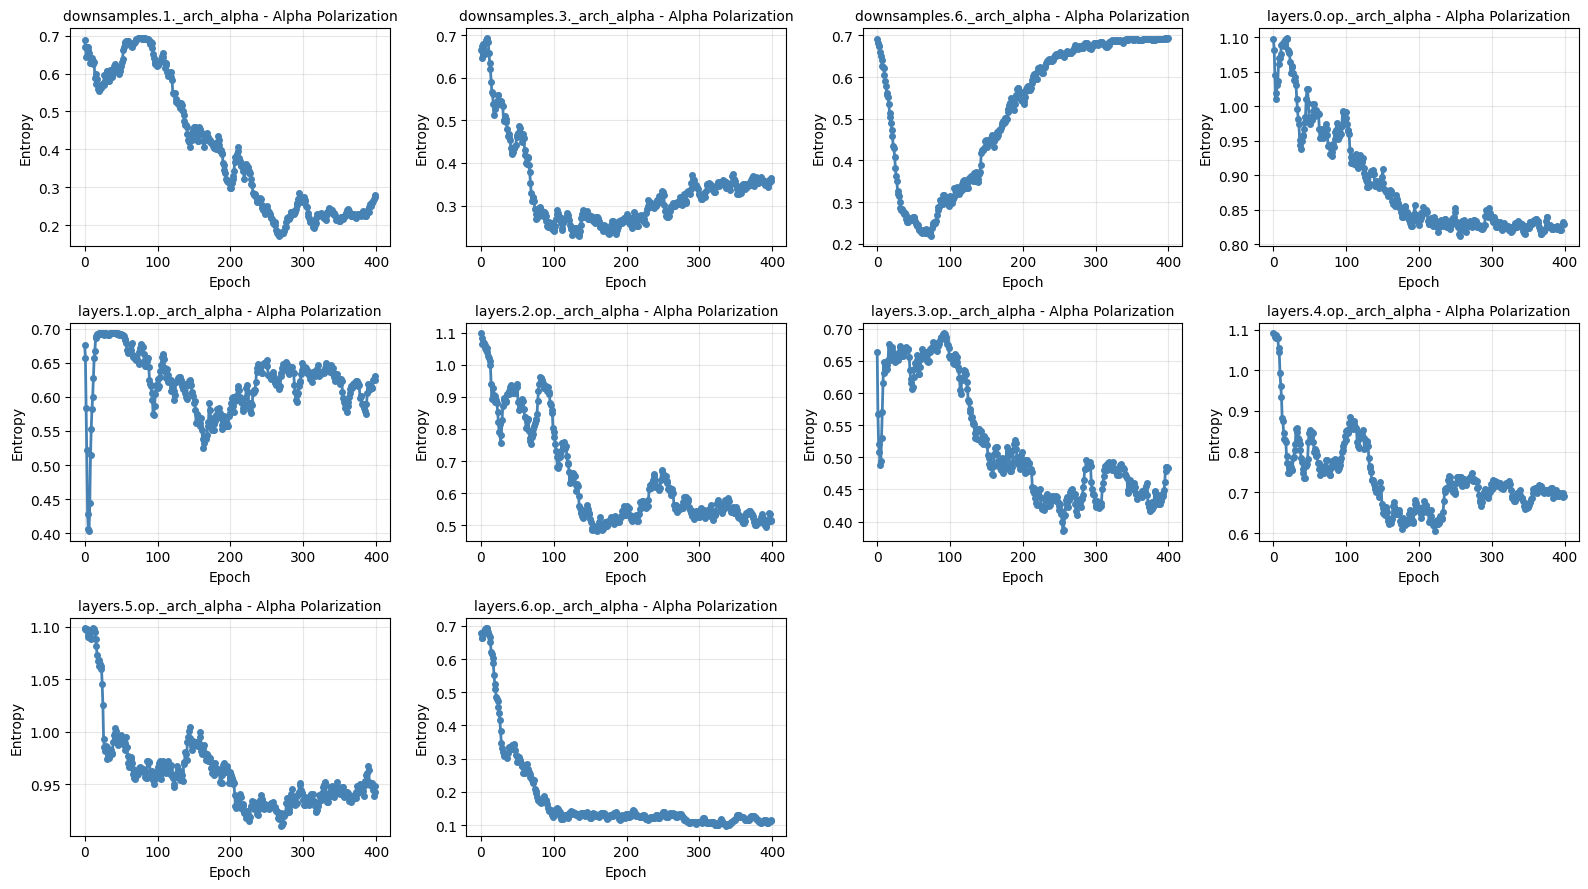


ALPHA POLARIZATION SUMMARY
downsamples.1._arch_alpha: entropy=0.2791, max_prob=0.9199, choice=0, Δentropy=0.4096
downsamples.3._arch_alpha: entropy=0.3656, max_prob=0.8807, choice=1, Δentropy=0.2996
downsamples.6._arch_alpha: entropy=0.6928, max_prob=0.5128, choice=1, Δentropy=-0.0005
layers.0.op._arch_alpha  : entropy=0.8293, max_prob=0.5260, choice=0, Δentropy=0.2683
layers.1.op._arch_alpha  : entropy=0.6250, max_prob=0.6825, choice=0, Δentropy=0.0506
layers.2.op._arch_alpha  : entropy=0.5131, max_prob=0.8543, choice=1, Δentropy=0.5855
layers.3.op._arch_alpha  : entropy=0.4838, max_prob=0.8116, choice=0, Δentropy=0.1800
layers.4.op._arch_alpha  : entropy=0.6910, max_prob=0.7739, choice=1, Δentropy=0.4001
layers.5.op._arch_alpha  : entropy=0.9478, max_prob=0.5895, choice=1, Δentropy=0.1506
layers.6.op._arch_alpha  : entropy=0.1123, max_prob=0.9762, choice=0, Δentropy=0.5666


In [19]:
# Load and visualize alpha evolution throughout the search
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'
if os.path.exists(alpha_history_path):
    history = torch.load(alpha_history_path, map_location='cpu')
    print(f"Loaded alpha history from {alpha_history_path}: {len(history)} epochs")
else:
    print(f"Warning: {alpha_history_path} not found. Run the search cell first.")
    history = None

if history is not None and len(history) > 0:
    # Get all alpha choice names from the first epoch
    alpha_names = sorted(list(history[0]['alphas'].keys()))
    num_alphas = len(alpha_names)
    print(f"Found {num_alphas} architectural choices")
    
    # Create figure with subplots for each alpha
    n_cols = 4
    n_rows = (num_alphas + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
    if num_alphas == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, name in enumerate(alpha_names):
        ax = axes[idx]
        
        # Extract probabilities for this alpha over all epochs
        probs_list = []
        for epoch_data in history:
            alpha_tensor = epoch_data['alphas'][name]
            probs = softmax(alpha_tensor)
            probs_list.append(probs)
        
        probs_array = np.array(probs_list)  # shape: (num_epochs, num_choices)
        
        # Plot entropy over epochs
        entropy = -np.sum(probs_array * np.log(probs_array + 1e-12), axis=1)
        ax.plot(entropy, linewidth=2, color='steelblue', marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Entropy')
        ax.set_title(f'{name} - Alpha Polarization', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(num_alphas, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png', dpi=150, bbox_inches='tight')
    print("Alpha evolution plot saved to /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png")
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("ALPHA POLARIZATION SUMMARY")
    print("="*60)
    for idx, name in enumerate(alpha_names):
        probs_list = []
        for epoch_data in history:
            probs = softmax(epoch_data['alphas'][name])
            probs_list.append(probs)
        probs_array = np.array(probs_list)
        
        # Final entropy
        final_entropy = -np.sum(probs_array[-1] * np.log(probs_array[-1] + 1e-12))
        max_prob_final = np.max(probs_array[-1])
        winning_choice = np.argmax(probs_array[-1])
        
        # Entropy change
        initial_entropy = -np.sum(probs_array[0] * np.log(probs_array[0] + 1e-12))
        entropy_change = initial_entropy - final_entropy
        
        print(f"{name:25s}: entropy={final_entropy:.4f}, max_prob={max_prob_final:.4f}, choice={winning_choice}, Δentropy={entropy_change:.4f}")

Using last captured epoch from alpha_history: 399
Choices captured: 10

=== FINAL SUPERNET ALPHA STATE (LAST EPOCH) ===
Choice Name                                   Entropy    Max Prob   Winner 
--------------------------------------------------------------------------------
downsamples.1                                 0.2791     0.9199     0      
downsamples.3                                 0.3656     0.8807     1      
downsamples.6                                 0.6928     0.5128     1      
layers.1.op                                   0.8293     0.5260     0      
layers.2.op                                   0.6250     0.6825     0      
layers.3.op                                   0.5131     0.8543     1      
layers.4.op                                   0.4838     0.8116     0      
layers.5.op                                   0.6910     0.7739     1      
layers.6.op                                   0.9478     0.5895     1      
layers.7.op                            

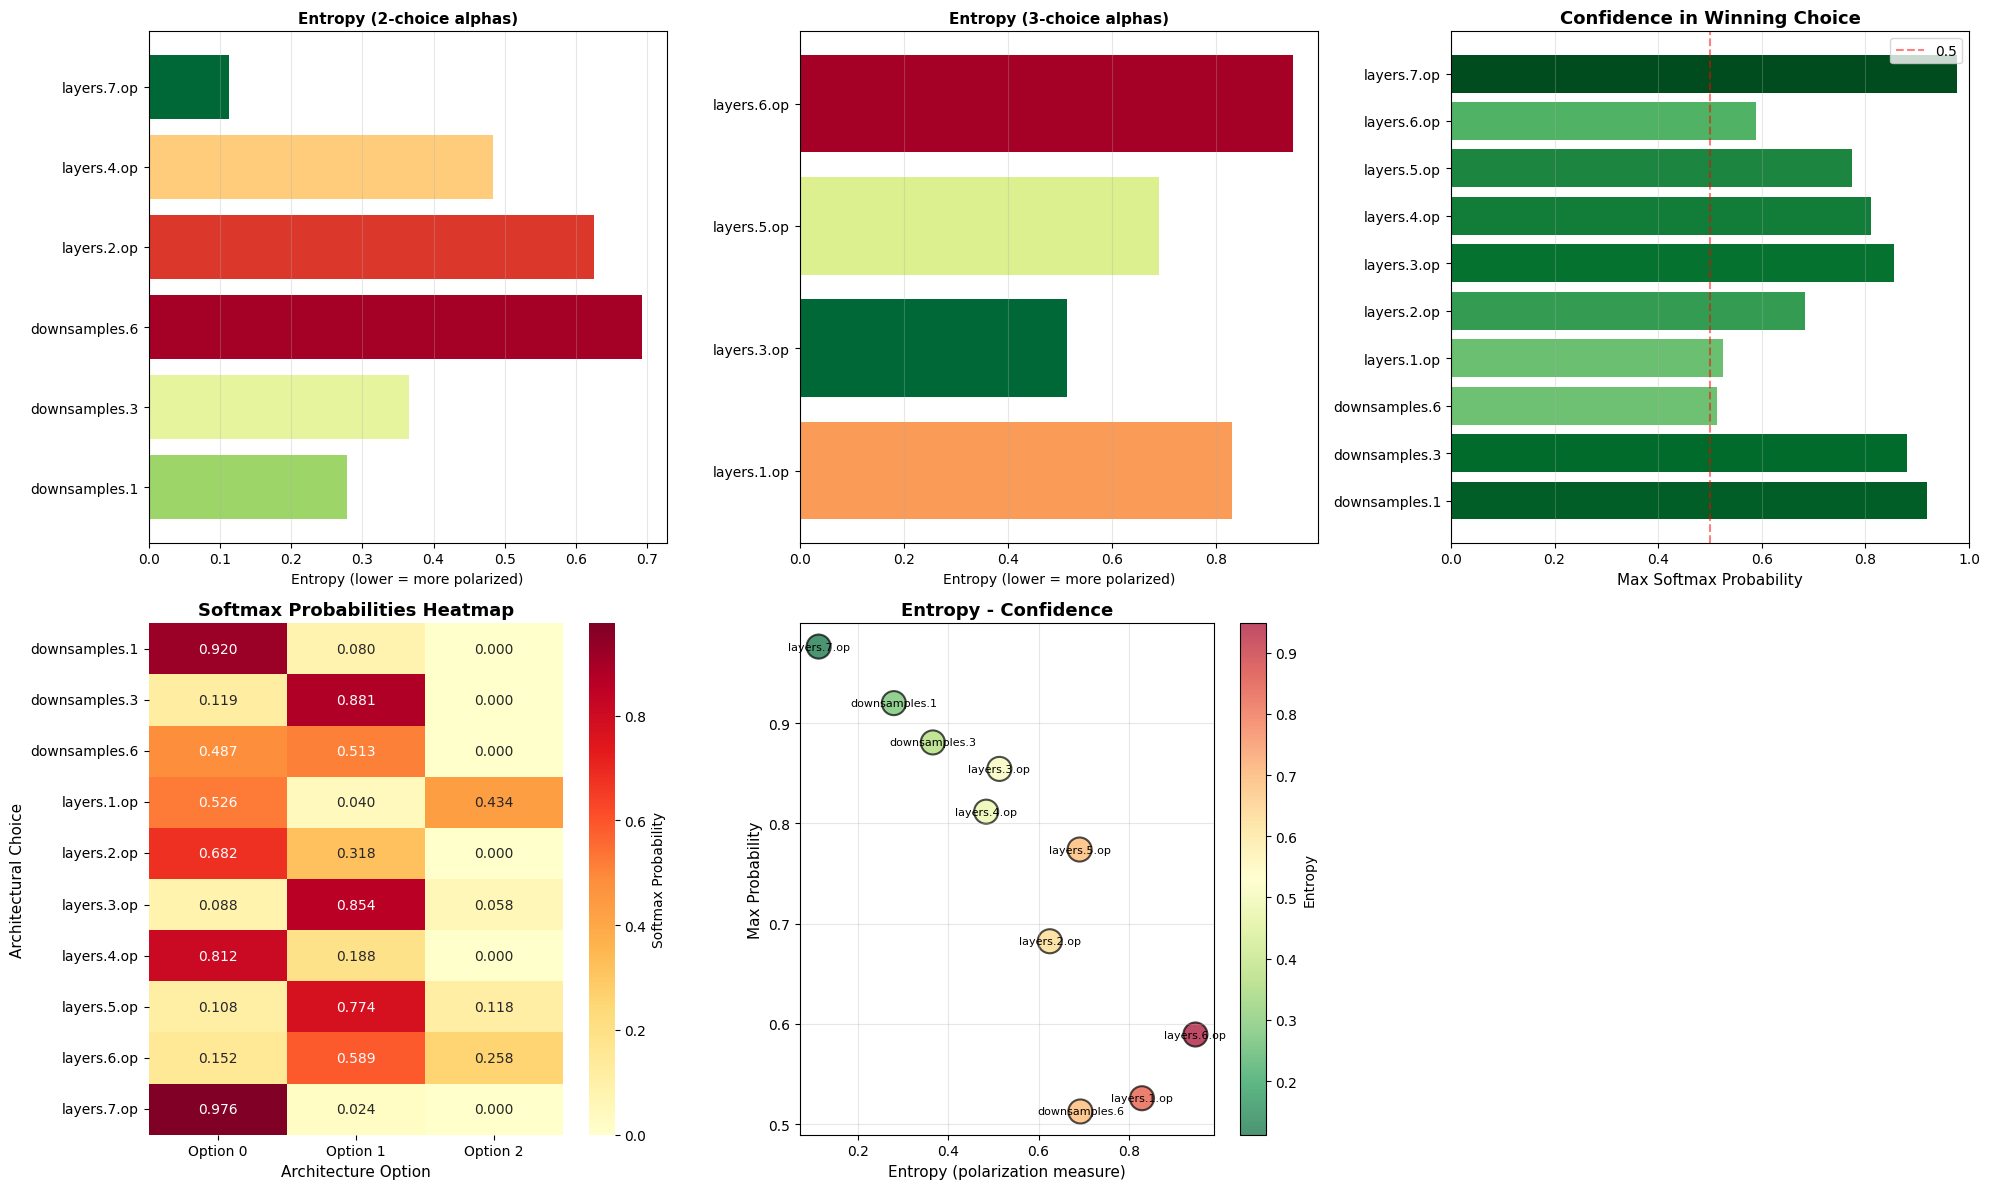

In [ ]:
# Final supernet state from alpha_history (last captured epoch)
import os
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'
if not os.path.exists(alpha_history_path):
    raise FileNotFoundError(f'alpha_history.pt not found at {alpha_history_path}. Run the search cell first.')

history = torch.load(alpha_history_path, map_location='cpu')
if not history:
    raise RuntimeError('alpha_history is empty; no epochs were captured.')

last_epoch = history[-1]
last_epoch_idx = last_epoch.get('epoch', len(history) - 1)
alphas = last_epoch['alphas']
print(f'Using last captured epoch from alpha_history: {last_epoch_idx}')
print(f'Choices captured: {len(alphas)}')

def _clean_choice_name(name: str) -> str:
    cleaned = name.replace('._arch_alpha.', '.').replace('_arch_alpha', '')
    cleaned = cleaned.replace('..', '.')
    def _bump_layers(match):
        return f"layers.{int(match.group(1)) + 1}"
    cleaned = re.sub(r"\blayers\.(\d+)\b", _bump_layers, cleaned)
    return cleaned.strip('.')

alpha_summary = {}
for name in sorted(alphas.keys()):
    alpha_tensor = alphas[name].float().numpy()
    exp_vals = np.exp(alpha_tensor - np.max(alpha_tensor))
    probs = exp_vals / np.sum(exp_vals)
    alpha_summary[name] = {
        'raw': alpha_tensor,
        'probs': probs,
        'entropy': -np.sum(probs * np.log(probs + 1e-12)),
        'max_prob': np.max(probs),
        'winning_choice': np.argmax(probs),
        'num_instances': 1,
        'label': _clean_choice_name(name),
    }

def _next_versioned_path(folder: str, base_name: str, ext: str) -> str:
    os.makedirs(folder, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(base_name)}_v(\d+){re.escape(ext)}$")
    max_v = 0
    for fname in os.listdir(folder):
        match = pattern.match(fname)
        if match:
            max_v = max(max_v, int(match.group(1)))
    return os.path.join(folder, f"{base_name}_v{max_v + 1}{ext}")

alpha_output_dir = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_polarization'
alpha_plot_path = _next_versioned_path(
    alpha_output_dir,
    'alpha_polarization_final_state_2bit',
    '.png',
)

print('\n=== FINAL SUPERNET ALPHA STATE (LAST EPOCH) ===')
print(f"{'Choice Name':<45} {'Entropy':<10} {'Max Prob':<10} {'Winner':<7}")
print('-' * 80)
for name in sorted(alpha_summary.keys()):
    data = alpha_summary[name]
    print(f"{data['label']:<45} {data['entropy']:<10.4f} {data['max_prob']:<10.4f} {int(data['winning_choice']):<7d}")

print('\nRaw probabilities per choice (last epoch):')
for name in sorted(alpha_summary.keys()):
    probs_str = np.array2string(alpha_summary[name]['probs'], precision=4, separator=', ')
    print(f"{alpha_summary[name]['label']}: {probs_str}")

def _plot_entropy_bars(ax, labels, entropies, title):
    if not entropies:
        ax.set_title(title, fontsize=11)
        ax.text(0.5, 0.5, 'No entries', ha='center', va='center')
        ax.axis('off')
        return
    ent_min, ent_max = min(entropies), max(entropies)
    normed = (np.array(entropies) - ent_min) / max(ent_max - ent_min, 1e-12)
    colors = plt.cm.RdYlGn(1.0 - normed)
    ax.barh(labels, entropies, color=colors)
    ax.set_xlabel('Entropy (lower = more polarized)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

# Create visualizations (same style as Cell 21)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Split by number of choices
two_choice_labels = []
two_choice_entropies = []
three_choice_labels = []
three_choice_entropies = []
for name in sorted(alpha_summary.keys()):
    label = alpha_summary[name]['label']
    entropy = alpha_summary[name]['entropy']
    num_choices = len(alpha_summary[name]['probs'])
    if num_choices == 2:
        two_choice_labels.append(label)
        two_choice_entropies.append(entropy)
    elif num_choices == 3:
        three_choice_labels.append(label)
        three_choice_entropies.append(entropy)

# 1. Entropy across 2-choice alphas
_plot_entropy_bars(axes[0, 0], two_choice_labels, two_choice_entropies, 'Entropy (2-choice alphas)')

# 2. Entropy across 3-choice alphas
_plot_entropy_bars(axes[0, 1], three_choice_labels, three_choice_entropies, 'Entropy (3-choice alphas)')

# 3. Max probability (winning choice confidence)
ax = axes[0, 2]
choice_names_sorted = [alpha_summary[name]['label'] for name in sorted(alpha_summary.keys())]
max_probs = [alpha_summary[name]['max_prob'] for name in sorted(alpha_summary.keys())]
colors_prob = plt.cm.Greens(np.array(max_probs))
ax.barh(choice_names_sorted, max_probs, color=colors_prob)
ax.set_xlabel('Max Softmax Probability', fontsize=11)
ax.set_title('Confidence in Winning Choice', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 4. Heatmap of softmax probabilities for each choice
ax = axes[1, 0]
heatmap_data = []
max_num_options = 0
for name in sorted(alpha_summary.keys()):
    probs = alpha_summary[name]['probs']
    heatmap_data.append(probs)
    max_num_options = max(max_num_options, len(probs))

heatmap_array = np.zeros((len(choice_names_sorted), max_num_options))
for i, probs in enumerate(heatmap_data):
    heatmap_array[i, :len(probs)] = probs

sns.heatmap(
    heatmap_array, annot=True, fmt='.3f', cmap='YlOrRd',
    yticklabels=choice_names_sorted, xticklabels=[f'Option {i}' for i in range(max_num_options)],
    ax=ax, cbar_kws={'label': 'Softmax Probability'}
 )
ax.set_title('Softmax Probabilities Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Architecture Option', fontsize=11)
ax.set_ylabel('Architectural Choice', fontsize=11)

# 5. Scatter plot: Entropy vs Max Probability
ax = axes[1, 1]
entropies_sorted = [alpha_summary[name]['entropy'] for name in sorted(alpha_summary.keys())]
scatter = ax.scatter(
    entropies_sorted, max_probs, s=300, c=entropies_sorted,
    cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=1.5
 )
for i, name in enumerate(choice_names_sorted):
    ax.annotate(
        name.replace('layer_', 'L').replace('feature', 'F'),
        (entropies_sorted[i], max_probs[i]),
        fontsize=8, ha='center', va='center'
    )
ax.set_xlabel('Entropy (polarization measure)', fontsize=11)
ax.set_ylabel('Max Probability', fontsize=11)
ax.set_title('Entropy - Confidence', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Entropy', fontsize=10)

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(alpha_plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved to: {alpha_plot_path}")
plt.show()

# Results and Best Architecture

In [21]:
# Export best architecture
best_arch = experiment_results.export_top_models(formatter='instance', top_k=1)[0]
best_arch_desc = experiment_results.export_top_models(formatter='dict', top_k=1)[0]
best_arch_state_dict = best_arch.state_dict()

print("Best Architecture Description:")
print(best_arch_desc)

Best Architecture Description:
{'layer_1_op': 0, 'layer_2_op': 1, 'layer_3_op': 0, 'layer_4_op': 0, 'layer_5_op': 0, 'layer_6_op': 0, 'layer_7_op': 1, 'layer_2_down': 0, 'layer_4_down': 0, 'layer_7_down': 0}


In [264]:
# Experiment configuration
print("Experiment Configuration:")
print(experiment_results.config)

Experiment Configuration:
NasExperimentConfig(experiment_name='PhotonicDARTS_Quant-v1', experiment_type='nas', search_space_file=None, search_space='_reserved_', trial_command='', trial_code_directory='.', trial_concurrency=1, trial_gpu_number=None, max_experiment_duration=None, max_trial_number=None, max_trial_duration=None, nni_manager_ip=None, use_annotation=False, debug=False, log_level=None, experiment_working_directory='./DartsCheckpoints_Quant', tuner_gpu_indices=None, tuner=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), assessor=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), advisor=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), training_service=LocalConfig(platform='local', trial_command=<dataclasses._MISSING_TYPE object at 0x7fee8e953ed0>, trial_code_directory=<dataclasses._MISSING_TYPE object at 0x7fee8e953ed0>, trial_gpu_number=<dataclasses._MISSING_TYPE obje

# Auto arch code generator

### Load Checkpoint

In [ ]:
checkpoint_path = './checkpoints/best-checkpoint-v31.ckpt'

checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

checkpoint_model = CustomDARTSSpace(input_channels=3, channels=64, num_classes=10, layers=7, verbose=0, num_bits=2)

checkpoint_state_dict = checkpoint_model.state_dict()
pretrained_state_dict = checkpoint['state_dict']

if 'global_step' in checkpoint:
    print('Global Step:', checkpoint['global_step'])

if 'callbacks' in checkpoint and isinstance(checkpoint['callbacks'], dict):
    for key, callback in checkpoint['callbacks'].items():
        if isinstance(callback, dict) and 'best_model_score' in callback:
            print('Best Model Score (Train Accuracy):', callback['best_model_score'].item())

Global Step: 64906
Best Model Score (Train Accuracy): 0.8500000238418579


In [ ]:
# # Inspect checkpoint contents relevant to supernet vs frozen export
# from collections import Counter

# checkpoint_path = './checkpoints/best-checkpoint.ckpt'
# ckpt = torch.load(checkpoint_path, map_location='cpu')
# sd = ckpt.get('state_dict', {})

# print('Checkpoint top-level keys:', list(ckpt.keys()))
# print('State dict tensor count:', len(sd))

# # Show the first several parameter names so we can see what is actually stored.
# for key in list(sd.keys())[:60]:
#     value = sd[key]
#     shape = tuple(value.shape) if hasattr(value, 'shape') else type(value)
#     print(key, shape)

# # Count the kinds of tensors that appear in the checkpoint.
# category_counts = Counter()
# for key in sd:
#     if 'arch_alpha' in key:
#         category_counts['arch_alpha'] += 1
#     elif 'bn' in key or 'batchnorm' in key.lower():
#         category_counts['batchnorm'] += 1
#     elif '.weight' in key or '.bias' in key:
#         category_counts['weights_or_biases'] += 1
#     else:
#         category_counts['other'] += 1

# print('\nTensor category counts:', dict(category_counts))


Checkpoint top-level keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers']
State dict tensor count: 147
training_module._model.layers.0._arch_alpha (2,)
training_module._model.layers.0.0.1.weight (64, 16, 3, 3)
training_module._model.layers.0.0.1._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.0.2.weight (64,)
training_module._model.layers.0.0.2.bias (64,)
training_module._model.layers.0.0.2.running_mean (64,)
training_module._model.layers.0.0.2.running_var (64,)
training_module._model.layers.0.0.2.num_batches_tracked ()
training_module._model.layers.0.0.2._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.1.0.weight (64, 16, 3, 3)
training_module._model.layers.0.1.0._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.1.2.weight (64,)
training_module._model.layers.0.1.2.bias (64,)
training_module._model.layers.0.1.2.running_mean (64,)
training_module._m

In [405]:
best_arch_desc

{'layer_1': 1,
 'layer1_out_channels': 32,
 'layer_2': 1,
 'layer2_out_channels': 16,
 'layer_3': 0,
 'layer3_out_channels': 64,
 'layer_4': 1,
 'layer4_out_channels': 64,
 'layer_5': 1,
 'layer5_out_channels': 16,
 'layer_6': 1,
 'layer6_out_channels': 16,
 'layer_7': 1,
 'feature1': 32,
 'feature2': 32,
 'feature3': 32}

# From-Scratch Model

In [23]:
import json
import os
import re

# Export the best architecture description to JSON for use in other scripts
def _next_versioned_path(folder: str, base_name: str, ext: str) -> str:
    os.makedirs(folder, exist_ok=True)
    pattern = re.compile(rf"^{re.escape(base_name)}_v(\d+){re.escape(ext)}$")
    max_v = 0
    for fname in os.listdir(folder):
        match = pattern.match(fname)
        if match:
            max_v = max(max_v, int(match.group(1)))
    return os.path.join(folder, f"{base_name}_v{max_v + 1}{ext}")

best_arch_dir = '/home/filippo/TESI_FILIPPO_LUCCHESI/best_arch_darts'
arch_export_path = _next_versioned_path(best_arch_dir, 'best_arch_darts_2bit', '.json')
with open(arch_export_path, 'w') as f:
    json.dump(best_arch_desc, f, indent=2)
print(f"Architecture exported to {arch_export_path}")
print("Architecture choices:", best_arch_desc)

Architecture exported to /home/filippo/TESI_FILIPPO_LUCCHESI/best_arch_darts/best_arch_darts_2bit_v1.json
Architecture choices: {'layer_1_op': 0, 'layer_2_op': 1, 'layer_3_op': 0, 'layer_4_op': 0, 'layer_5_op': 0, 'layer_6_op': 0, 'layer_7_op': 1, 'layer_2_down': 0, 'layer_4_down': 0, 'layer_7_down': 0}


In [26]:
import json
import os
import glob

best_arch_dir = "/home/filippo/TESI_FILIPPO_LUCCHESI/best_arch_darts"
pattern = os.path.join(best_arch_dir, "best_arch_darts_2bit*.json")
candidates = glob.glob(pattern)
if not candidates:
    raise FileNotFoundError(f"No files found for pattern: {pattern}")

arch_path = max(candidates, key=os.path.getmtime)
print(f"Loading latest architecture file: {arch_path}")

with open(arch_path, "r") as f:
    arch_dict = json.load(f)

print("Loaded arch_dict keys:", sorted(arch_dict.keys()))

Loading latest architecture file: /home/filippo/TESI_FILIPPO_LUCCHESI/best_arch_darts/best_arch_darts_2bit_v1.json
Loaded arch_dict keys: ['layer_1_op', 'layer_2_down', 'layer_2_op', 'layer_3_op', 'layer_4_down', 'layer_4_op', 'layer_5_op', 'layer_6_op', 'layer_7_down', 'layer_7_op']


In [79]:
max_epochs = 400
num_bits = 2

class ActQuant(nn.Module):
    def __init__(self, k=6, init_step=0.5):
        super().__init__()

        self.k = k

        # learned quantization step size
        self.step_size = nn.Parameter(torch.tensor(init_step))

        self.alpha = nn.Parameter(torch.tensor(6.0))

    def forward(self, x):

        # positive step size
        s = torch.clamp(self.step_size, min=1e-8)

        Qn = 0
        Qp = (2 ** self.k) - 1

        # scale gradient like LSQ paper
        grad_scale = 1.0 / ((Qp * x.numel()) ** 0.5)

        s_scale = (s - s.detach()) * grad_scale + s.detach()

        alpha = torch.clamp(self.alpha, min=1e-8)

        x = torch.clamp(x, torch.zeros_like(x), alpha)

        # quantize
        x_div = x / s_scale
        x_clamped = torch.clamp(x_div, Qn, Qp)

        x_q = torch.round(x_clamped)

        # STE
        x_q = x_clamped + (x_q - x_clamped).detach()

        return x_q * s_scale

from DoReFaLayers import FrozenDoReFaConv2d, FrozenDoReFaLinear, dorefa_activation


class FrozenResidualBlock(torch.nn.Module):
    def __init__(self, op: torch.nn.Module, in_channels: int, out_channels: int, num_bits: int):
        super().__init__()
        self.op = op
        if in_channels != out_channels:
            self.proj = torch.nn.Sequential(
                FrozenDoReFaConv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=1,
                    padding=0,
                    bias=False,
                    num_bits=num_bits,
                ),
                torch.nn.BatchNorm2d(out_channels),
            )
        else:
            self.proj = torch.nn.Identity()
        self.post_relu = torch.nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor, w_quant_bits: int) -> torch.Tensor:
        out = x
        for sublayer in self.op:
            if isinstance(sublayer, (FrozenDoReFaConv2d, FrozenDoReFaLinear)):
                out = sublayer(out, w_quant_bits)
            else:
                out = sublayer(out)

        if isinstance(self.proj, torch.nn.Identity):
            res = x
        else:
            res = x
            for sublayer in self.proj:
                if isinstance(sublayer, (FrozenDoReFaConv2d, FrozenDoReFaLinear)):
                    res = sublayer(res, w_quant_bits)
                else:
                    res = sublayer(res)
        return self.post_relu(out + res * 0.5)


class PhotonicArchQuant(torch.nn.Module):  #quickg
    def __init__(self, drop_path_prob=0.0, arch_dict=None, num_bits=2, max_epochs=500, exit_points=None, early_exit=False, exit_thresholds=None, warmup_fp_epochs: int = 0):
        super().__init__()
        if arch_dict is None:
            raise ValueError("arch_dict is required to build PhotonicArchQuant")
        self.arch_dict = arch_dict
        self.drop_path_prob = drop_path_prob
        self.num_bits = num_bits
        self.max_epochs = max_epochs
        self.warmup_fp_epochs = int(warmup_fp_epochs)
        self.exit_points = exit_points
        self.early_exit = early_exit
        self.exit_thresholds = exit_thresholds
        in_channels = 64

        self.preliminary_layer = FrozenDoReFaConv2d(3, in_channels, kernel_size=3, padding=1, bias=False, num_bits=num_bits)
        self.layer0_bn = torch.nn.BatchNorm2d(in_channels)
        self.layer0_relu = torch.nn.ReLU(inplace=False)

        default_out_channels = [64, 128, 128, 256, 256, 256, 512]
        layer_out_channels = [
            arch_dict.get('layer1_out_channels', default_out_channels[0]),
            arch_dict.get('layer2_out_channels', default_out_channels[1]),
            arch_dict.get('layer3_out_channels', default_out_channels[2]),
            arch_dict.get('layer4_out_channels', default_out_channels[3]),
            arch_dict.get('layer5_out_channels', default_out_channels[4]),
            arch_dict.get('layer6_out_channels', default_out_channels[5]),
            arch_dict.get('layer7_out_channels', default_out_channels[6]),
        ]

        self.layers = torch.nn.ModuleList()
        self.downsamples = torch.nn.ModuleList()
        for layer_index, out_channels in enumerate(layer_out_channels, start=1):
            op_choice = arch_dict.get(f'layer_{layer_index}_op', arch_dict.get(f'layer_{layer_index}', 0))
            if op_choice == 0:
                op = torch.nn.Sequential(
                    FrozenDoReFaConv2d(
                        in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False, num_bits=num_bits
                    ),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            elif op_choice == 1:
                op = torch.nn.Sequential(
                    FrozenDoReFaConv2d(
                        in_channels, in_channels, kernel_size=3, stride=1, padding=1, groups=in_channels,
                        bias=False, num_bits=num_bits
                    ),
                    torch.nn.BatchNorm2d(in_channels),
                    torch.nn.ReLU(inplace=False),
                    FrozenDoReFaConv2d(
                        in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False, num_bits=num_bits
                    ),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            elif op_choice == 2:
                op = torch.nn.Sequential(
                    SkipConnect(in_channels, out_channels, num_bits=num_bits)
                )
            self.layers.append(FrozenResidualBlock(op, in_channels, out_channels, num_bits))

            downsample_choice = None
            if layer_index in (2, 4, 7):
                downsample_choice = arch_dict.get(f'layer_{layer_index}_down', 0)
            if downsample_choice == 0:
                self.downsamples.append(torch.nn.AvgPool2d(kernel_size=2, stride=2))
            elif downsample_choice == 1:
                self.downsamples.append(
                    torch.nn.Sequential(
                        FrozenDoReFaConv2d(
                            out_channels, out_channels, kernel_size=1, stride=2, padding=0, bias=False, num_bits=num_bits
                        ),
                        torch.nn.BatchNorm2d(out_channels),
                    )
                )
            else:
                self.downsamples.append(torch.nn.Identity())
            in_channels = out_channels

        self.pool = torch.nn.AdaptiveAvgPool2d(1)
        self.classifier = FrozenDoReFaLinear(layer_out_channels[-1], 10, num_bits=num_bits)
        self.dropout = torch.nn.Dropout(0.2)
        self.actQuantPre = ActQuant(k=num_bits)
        self.actQuantPost = ActQuant(k=num_bits)
        self.actQuants = nn.ModuleList([
            ActQuant(k=num_bits) for _ in range(len(layer_out_channels))
        ])

        if exit_points is None:
            exit_points = [3, 5, 7]
        self.exit_points = sorted(set(exit_points))
        self.exit_heads = torch.nn.ModuleDict()
        for layer_index in self.exit_points:
            if 1 <= layer_index <= len(layer_out_channels):
                out_channels = layer_out_channels[layer_index - 1]
                self.exit_heads[str(layer_index)] = self._make_exit_head(out_channels, num_bits)

    def _make_exit_head(self, in_channels: int, num_bits: int) -> torch.nn.Module:
        return torch.nn.Sequential(
            torch.nn.AdaptiveAvgPool2d(1),
            torch.nn.Flatten(),
            FrozenDoReFaLinear(in_channels, 10, num_bits=num_bits),
        )

    def _exit_confidence(self, logits: torch.Tensor) -> torch.Tensor:
        probs = torch.softmax(logits, dim=1)
        return probs.max(dim=1).values

    def _forward_core(self, x, act_quant_bits, w_quant_bits, pre_act_bits=None, post_act_bits=None, early_exit=False, exit_thresholds=None, return_all_exits=False, use_act_quant: bool = True):
        if use_act_quant and pre_act_bits is not None:
            x = self.actQuantPre(x)
        x = self.preliminary_layer(x, w_quant_bits)
        x = self.layer0_bn(x)
        x = self.layer0_relu(x)

        exit_logits = []
        for i, block in enumerate(self.layers, start=1):
            if use_act_quant:
                x = self.actQuants[i - 1](x)
            if isinstance(block, FrozenResidualBlock):
                x = block(x, w_quant_bits)
            else:
                for sublayer in block:
                    if isinstance(sublayer, (FrozenDoReFaConv2d, FrozenDoReFaLinear)):
                        x = sublayer(x, w_quant_bits)
                    else:
                        x = sublayer(x)
            
            downsample = self.downsamples[i - 1]
            if not isinstance(downsample, torch.nn.Identity):
                x = downsample(x)

            if str(i) in self.exit_heads:
                head_logits = self.exit_heads[str(i)](x)
                exit_logits.append((i, head_logits))
                if early_exit and not self.training:
                    threshold = None
                    if isinstance(exit_thresholds, dict):
                        threshold = exit_thresholds.get(i)
                    elif isinstance(exit_thresholds, (list, tuple)) and len(exit_thresholds) >= len(exit_logits):
                        threshold = exit_thresholds[len(exit_logits) - 1]
                    if threshold is not None:
                        confidence = self._exit_confidence(head_logits)
                        if torch.all(confidence >= float(threshold)):
                            print(f"Early exiting at layer {i} with confidence {confidence.item():.4f} (threshold: {threshold})")
                            return head_logits#, i

        
        x = self.pool(x)
        x = torch.flatten(x, 1)
        #x = self.dropout(x)
        if use_act_quant and post_act_bits is not None:
            x = self.actQuantPost(x)
        x = self.classifier(x)
        if return_all_exits:
            exit_logits.append((len(self.layers), x))
            return x, exit_logits
        if early_exit and not self.training:
            print("this shouldnt print if return_all_exits is T")
            return x, len(self.layers)
        return x

    def forward_train(self, x, epoch: int = 0, return_all_exits: bool = False):
        use_fp = epoch < self.warmup_fp_epochs
        act_quant_bits = self.num_bits
        w_quant_bits = None if use_fp else self.num_bits
        pre_act_bits = None if use_fp else self.num_bits
        post_act_bits = None if use_fp else self.num_bits
        return self._forward_core(
            x,
            act_quant_bits,
            w_quant_bits,
            pre_act_bits,
            post_act_bits,
            return_all_exits=return_all_exits,
            use_act_quant=not use_fp,
        )

    def forward_infer(self, x, num_bits: int | None = None, early_exit: bool = False, exit_thresholds=None, return_all_exits: bool = False):
        if num_bits is None:
            num_bits = self.num_bits
        return self._forward_core(
            x,
            num_bits,
            num_bits,
            pre_act_bits=num_bits,
            post_act_bits=num_bits,
            early_exit=early_exit,
            exit_thresholds=exit_thresholds,
            return_all_exits=return_all_exits,
        )

    def forward(self, x, epoch: int | None = None, inference: bool = False, return_all_exits: bool = False):
        if epoch is None or epoch == 0:
            epoch = getattr(self, 'epoch', epoch)
        self.epoch = 0 if epoch is None else epoch
        if inference or not self.training:
            return self.forward_infer(x, early_exit=self.early_exit, exit_thresholds=self.exit_thresholds, return_all_exits=return_all_exits)
        return self.forward_train(x, self.epoch, return_all_exits=return_all_exits)
    
    def init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def set_drop_path_prob(self, drop_path_prob):
        self.drop_path_prob = drop_path_prob

In [86]:
exit_thresholds = {
    3: 0.90,
    5: 0.95,
    7: 0.98,
}
warmup_fp_epochs = 10
scratch_model = PhotonicArchQuant(
    arch_dict=arch_dict,
    num_bits=num_bits,
    early_exit=False,
    max_epochs=max_epochs,
    warmup_fp_epochs=warmup_fp_epochs,
 )
scratch_model
for m in scratch_model.modules():
    if isinstance(m, ActQuant):
        m.step_size.data.fill_(0.05)

In [38]:
# Sanity check: early-exit outputs and auxiliary-loss format
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scratch_model.to(device)
scratch_model.eval()

with torch.no_grad():
    inputs, labels = next(iter(train_loader))
    inputs, labels = inputs.to(device), labels.to(device)
    final_logits, exits = scratch_model(inputs, inference=True, return_all_exits=True)
    print("Final logits shape:", tuple(final_logits.shape))
    print("Exit heads:", [layer for layer, _ in exits])
    print("Exit shapes:", [tuple(logits.shape) for _, logits in exits])

Final logits shape: (128, 10)
Exit heads: [3, 5, 7, 7]
Exit shapes: [(128, 10), (128, 10), (128, 10), (128, 10)]


### Rename dictionary keys

In [77]:
best_arch_state_dict = scratch_model.state_dict()

## Load weights

In [284]:
scratch_model.load_state_dict(best_arch_state_dict)

<All keys matched successfully>

In [55]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total_samples
    return avg_loss, accuracy

In [84]:
from pytorch_lightning.callbacks import Callback

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class StopOnValAccDrop(Callback):
    def __init__(self, drop_tolerance: float = 0.02, metric_name: str = "val_acc"):
        super().__init__()
        self.drop_tolerance = drop_tolerance
        self.metric_name = metric_name
        self.best = None

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if self.metric_name not in metrics:
            return
        current = metrics[self.metric_name]
        current_val = float(current.detach().cpu()) if hasattr(current, "detach") else float(current)
        if self.best is None or current_val > self.best:
            self.best = current_val
            return
        if (current_val < self.best - self.drop_tolerance) and (current_val > 0.88):
            print(
                f"Early stopping: {self.metric_name} dropped from {self.best:.4%} to {current_val:.4%} "
                f"(tolerance {self.drop_tolerance:.2%})."
            )
            trainer.should_stop = True


scratch_model.to(device)
scratch_model.init_weights()
scratch_model.train()
module = DartsClassificationModule(2e-2, 0., 0., max_epochs)
module.set_model(scratch_model)


val_acc_drop_tolerance = 0.02
early_stop_callback = StopOnValAccDrop(
    drop_tolerance=val_acc_drop_tolerance,
    metric_name="val_acc",
)
trainer = Trainer(
    max_epochs=module.max_epochs,
    accelerator="auto",
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback],
)

GPU available: True (cuda), used: True
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [63]:
# Auxiliary-exit demo: pass weights and compute main/aux losses on one batch


inputs, labels = next(iter(train_loader))
inputs, labels = inputs.to(device), labels.to(device)
model = getattr(module, "_model", getattr(module, "model", None))
if model is None:
    raise RuntimeError("DartsClassificationModule has no attached model.")
model.train()
outputs = model(inputs, inference=True, return_all_exits=True)
y_hat, exit_logits = module._resolve_outputs(outputs)
loss_main = module.criterion(y_hat, labels)
loss_aux = module._compute_aux_exit_loss(exit_logits, labels)
print("loss_main:", float(loss_main), "loss_aux:", None if loss_aux is None else float(loss_aux))

loss_main: 2.8592989444732666 loss_aux: None


In [ ]:
# Get the current Jupyter kernel process
p = psutil.Process(os.getpid())

# Set the niceness to 19 (Lowest CPU priority)
p.nice(19)

aux_weights = [0.2] * max(1, len(getattr(scratch_model, "exit_points", [])))
module = DartsClassificationModule(2e-2, 0.0, auxiliary_loss_weight=None, max_epochs=max_epochs, auxiliary_exit_weights=None)
module.set_model(scratch_model)
scratch_model.early_exit = False
module.train()

trainer.fit(module, train_loader, valid_loader)

/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/filippo/TESI_FILIPPO_LUCCHESI/lightning_logs/version_211/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | criterion | CrossEntropyLoss  | 0      | train | 0    
1 | metrics   | ModuleDict        | 0      | train | 0    
2 | _model    | PhotonicArchQuant | 2.0 M  | train | 0    
----------------------------------------------------------------
2.0 M     Trainable params
0         Non-trainable params
2.0 M     Total params
7.979     Total estimated model params size (MB)
120       Modules in train mode
0         Modules in eval mode
0         Total Flops

  | Name      | Type              | Params | Mode  | FLOPs
-----------------------------

Weight params: 56
Arch params (excluded): 9
Epoch 2:  53%|█████████████████▉                | 206/391 [01:01<00:55,  3.35it/s, v_num=211, train_loss=2.310, train_acc=0.0859, val_loss=2.300, val_acc=0.100]
Training: |                                                                                                                               | 0/? [00:00<?, ?it/s]
=== Attached alpha gradient hooks ===

Epoch 285:  34%|███████████                      | 131/391 [00:20<00:40,  6.48it/s, v_num=211, train_loss=0.689, train_acc=0.766, val_loss=0.650, val_acc=0.774]

In [91]:
criterion = nn.CrossEntropyLoss()
scratch_model.to(device)

valid_loader = DataLoader(
    test_data, batch_size=batch_size,
    pin_memory=True, num_workers=0, persistent_workers=False
)

scratch_model.eval()
total_loss = 0.0
correct = 0
total_samples = 0
correct_flags = []

with torch.no_grad():
    for inputs, labels in valid_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = scratch_model(inputs)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        batch_correct = preds.eq(labels).detach().cpu().numpy().astype(np.float32)
        correct_flags.extend(batch_correct.tolist())
        correct += int(batch_correct.sum())
        total_samples += labels.size(0)

avg_loss = total_loss / max(1, len(valid_loader))
accuracy = correct / max(1, total_samples)

if correct_flags:
    correct_arr = np.array(correct_flags, dtype=np.float32)
    n_boot = 1000
    rng = np.random.default_rng(0)
    boot_accs = np.empty(n_boot, dtype=np.float32)
    n = len(correct_arr)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_accs[i] = correct_arr[idx].mean()
    max_acc = float(boot_accs.max())
    min_acc = float(boot_accs.min())
    ci_low, ci_high = np.percentile(boot_accs, [2.5, 97.5]).tolist()
else:
    max_acc = float("nan")
    min_acc = float("nan")
    ci_low = float("nan")
    ci_high = float("nan")

print(f"Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4%}")
print(f"Max val acc (bootstrap): {max_acc:.4%}")
print(f"Min val acc (bootstrap): {min_acc:.4%}")
print(f"95% CI (bootstrap acc): [{ci_low:.4%}, {ci_high:.4%}]")

Validation Loss: 0.6348, Accuracy: 77.9900%
Max val acc (bootstrap): 79.4200%
Min val acc (bootstrap): 76.6000%
95% CI (bootstrap acc): [77.2200%, 78.8000%]


In [92]:
# Save the trained scratch model to disk
model_save_path = "/home/filippo/TESI_FILIPPO_LUCCHESI/scratch_model_2bit.pt"
torch.save(scratch_model.state_dict(), model_save_path)
print(f"Saved scratch model state_dict to: {model_save_path}")

Saved scratch model state_dict to: /home/filippo/TESI_FILIPPO_LUCCHESI/scratch_model_2bit.pt


In [160]:
# Tune early-exit confidence thresholds on validation data
thresholds = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 1.0]
max_batches = None  # set to None to use the full validation set
model = scratch_model
model.to(device)
model.eval()

exit_points = getattr(model, "exit_points", [])
if not exit_points:
    raise RuntimeError("No exit points found on the model.")

single_loader = DataLoader(
    test_data,
    batch_size=1,
    pin_memory=True,
    num_workers=0,
    persistent_workers=False,
    shuffle=False,
    drop_last=False,
 )

def _choose_exit_layer(exits, thresholds_by_layer):
    chosen_layer = exits[-1][0]
    chosen_logits = exits[-1][1]
    for layer_idx, head_logits in exits:
        threshold = thresholds_by_layer.get(int(layer_idx))
        if threshold is None:
            continue
        confidence = torch.softmax(head_logits, dim=1).max().item()
        if confidence >= float(threshold):
            return layer_idx, head_logits
    return chosen_layer, chosen_logits

with torch.no_grad():
    for thr in thresholds:
        thr_dict = {int(p): float(thr) for p in exit_points}
        total = 0
        correct = 0
        exit_layer_sum = 0
        used_batches = 0
        for inputs, labels in single_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            final_logits, exits = model(
                inputs,
                inference=True,
                return_all_exits=True,
            )
            exit_layer, logits = _choose_exit_layer(exits, thr_dict)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            exit_layer_sum += int(exit_layer) * labels.size(0)
            used_batches += 1
            if max_batches is not None and used_batches >= max_batches:
                break
        acc = correct / max(1, total)
        avg_exit = exit_layer_sum / max(1, total)
        print(f"thr={thr:.2f}  acc={acc:.4%}  avg_exit_layer={avg_exit:.2f}")

thr=0.60  acc=77.2700%  avg_exit_layer=3.65
thr=0.70  acc=79.4600%  avg_exit_layer=4.00
thr=0.80  acc=81.7000%  avg_exit_layer=4.40
thr=0.85  acc=82.6200%  avg_exit_layer=4.65
thr=0.90  acc=83.6400%  avg_exit_layer=4.96
thr=0.95  acc=85.2500%  avg_exit_layer=5.38
thr=1.00  acc=89.7200%  avg_exit_layer=7.00
